<a href="https://colab.research.google.com/github/indujagannathan/Internship-/blob/main/INDUJAGAN3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

In [4]:
Data= pd.read_csv('/content/drive/MyDrive/data.csv')

In [5]:
Data.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                               Sentence sentiment_label
0     The GeoSolutions technology will leverage Bene...        positive
1     $ESI on lows, down $1.50 to $2.50 BK a real po...        negative
2     For the last quarter of 2010 , Componenta 's n...        positive
3     According to the Finnish-Russian Chamber of Co...         neutral
4     The Swedish buyout firm has sold its remaining...         neutral
...                                                 ...             ...
5837  RISING costs have forced packaging producer Hu...        negative
5838  Nordic Walking was first used as a summer trai...         neutral
5839  According shipping company Viking Line , the E...        positive
5840  In the building and home improvement trade , s...        positive
5841  HELSINKI AFX - KCI Konecranes said it has won ...         neutral

[5842 rows x 2 columns]


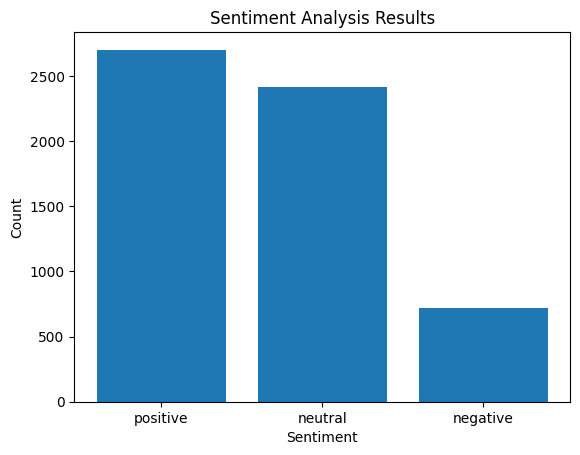

In [7]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt


from google.colab import drive
drive.mount('/content/drive')

nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('stopwords')


Data= pd.read_csv('/content/drive/MyDrive/data.csv')


sia = SentimentIntensityAnalyzer()

def preprocess_text(text):

    tokens = word_tokenize(text)


    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token.lower() not in stop_words]


    text = ' '.join(tokens)

    return text


Data['text'] = Data['Sentence'].apply(preprocess_text)


Data['sentiment'] = Data['text'].apply(lambda text: sia.polarity_scores(text)['compound'])


def classify_sentiment(sentiment):
    if sentiment >= 0.05:
        return 'positive'
    elif sentiment <= -0.05:
        return 'negative'
    else:
        return 'neutral'


Data['sentiment_label'] = Data['sentiment'].apply(classify_sentiment)


print(Data[['Sentence', 'sentiment_label']])


sentiment_counts = Data['sentiment_label'].value_counts()


plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Analysis Results')
plt.show()